# Face Identification & Blockchain Verification Pipeline
### HH Goa 2026 — Shortlisting Task 3

**Pipeline:** Face scan → Web/social media search (find matching post) → Blockchain upload/verification

This notebook is fully self-contained and runnable top-to-bottom. Every place you need to
provide your own input (an image, an API key, a wallet key) is clearly marked **`# <-- EDIT`**.

**Stages:**
1. Face detection & encoding (local, open-source, no API key needed)
2. Reverse image search to find a real matching post on the web (needs a free SerpApi key)
3. Blockchain fingerprinting & verification (local simulated chain by default, or a real Ethereum Sepolia testnet transaction if you opt in)

Run cells in order. Cells that need your input are grouped under **"CONFIG"** below.


## 0. Install dependencies
Run this once. If `face_recognition` fails to install (it needs `dlib`/`cmake`), the notebook will automatically fall back to an OpenCV-only face detector — the pipeline still runs end to end, just with a weaker fallback encoding instead of a proper 128-d face embedding.

In [ ]:
import subprocess, sys

def pip_install(*packages):
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", *packages], check=True)

# Core deps (safe on almost any machine)
pip_install("opencv-python-headless", "requests", "pillow", "matplotlib", "numpy", "python-dotenv")

# Face recognition (needs dlib under the hood — usually installs fine on Colab / Linux / Mac,
# can be finicky on some Windows setups). Wrapped so the rest of the notebook still works if it fails.
try:
    pip_install("face_recognition")
except Exception as e:
    print("face_recognition install had an issue, will use OpenCV fallback instead:", e)

# Only needed if you switch USE_REAL_BLOCKCHAIN = True later (real Sepolia testnet transaction)
pip_install("web3")


## 1. CONFIG — edit these values
This is the only section you should need to touch to run the whole pipeline.

- **`IMAGE_PATH`** — path to a face photo on disk (upload it into the same folder as this notebook first).
- **`SERPAPI_KEY`** — free key from https://serpapi.com/manage-api-key (250 free searches/month, no card needed for the free tier).
  You can either paste it directly below, set it as an environment variable `SERPAPI_KEY`, or leave it blank and you'll be prompted securely at runtime.
- **`USE_REAL_BLOCKCHAIN`** — leave `False` to use a local simulated blockchain (no cost, no setup, fully satisfies the task's "local/simulated chain" option).
  Set `True` only if you want to anchor the hash on the real Ethereum **Sepolia testnet** (needs a free RPC URL + a testnet-only wallet with faucet ETH — see Section 5).


In [5]:
import os
from getpass import getpass

try:
    from dotenv import load_dotenv
    try:
        load_dotenv(override=False)
    except Exception:
        pass
except ImportError:
    load_dotenv = None
    print("python-dotenv is not installed. Run: pip install python-dotenv")

# ---- 1a. Input image -------------------------------------------------------
# Set this to a real image path in the same folder as the notebook or anywhere on disk.
IMAGE_PATH = os.environ.get("IMAGE_PATH", "")
if not IMAGE_PATH:
    IMAGE_PATH = "/home/ubuntu/workspace/Elon_Musk_Royal_Society.jpg"
    # IMAGE_PATH = ""

# Optional: if you already have a publicly available image URL, set it here; the notebook
# will use it instead of trying to upload the local file.
PUBLIC_IMAGE_URL = os.environ.get("PUBLIC_IMAGE_URL", "").strip()
# PUBLIC_IMAGE_URL = "https://upload.wikimedia.org/wikipedia/commons/thumb/e/ed/Elon_Musk_Royal_Society.jpg/250px-Elon_Musk_Royal_Society.jpg?utm_source=en.wikipedia.org&utm_campaign=parser&utm_content=thumbnail"

# ---- 1b. SerpApi key (reverse image search) --------------------------------
SERPAPI_KEY = ""                # <-- EDIT: paste your key here (or leave blank to be prompted)
SERPAPI_KEY = SERPAPI_KEY or os.environ.get("SERPAPI_KEY", "")
# if not SERPAPI_KEY:
    # SERPAPI_KEY = getpass("Enter your SerpApi key (input hidden, get one free at https://serpapi.com/manage-api-key): ")

# ---- 1c. Blockchain mode ----------------------------------------------------
USE_REAL_BLOCKCHAIN = False     # <-- EDIT: set True to anchor on Sepolia testnet instead of the local simulated chain

# Only needed if USE_REAL_BLOCKCHAIN = True
SEPOLIA_RPC_URL = ""            # <-- EDIT: e.g. an Alchemy/Infura Sepolia HTTPS RPC URL
WALLET_PRIVATE_KEY = ""         # <-- EDIT: private key of a TESTNET-ONLY wallet. NEVER use a real/mainnet wallet's key here.
if USE_REAL_BLOCKCHAIN:
    SEPOLIA_RPC_URL = SEPOLIA_RPC_URL or os.environ.get("SEPOLIA_RPC_URL", "")
    WALLET_PRIVATE_KEY = WALLET_PRIVATE_KEY or os.environ.get("WALLET_PRIVATE_KEY", "")
    if not SEPOLIA_RPC_URL:
        SEPOLIA_RPC_URL = getpass("Enter your Sepolia RPC URL (hidden): ")
    if not WALLET_PRIVATE_KEY:
        WALLET_PRIVATE_KEY = getpass("Enter your TESTNET wallet private key (hidden): ")

if not os.path.exists(IMAGE_PATH):
    print(f"Warning: IMAGE_PATH '{IMAGE_PATH}' does not exist yet. Put your image there before running Stage 1.")

print("Config loaded.")
print("Image path        :", IMAGE_PATH)
print("Public URL set    :", bool(PUBLIC_IMAGE_URL))
print("SerpApi key set   :", bool(SERPAPI_KEY))
print("Blockchain mode    :", "REAL Sepolia testnet" if USE_REAL_BLOCKCHAIN else "Local simulated chain")


Config loaded.
Image path        : /home/ubuntu/workspace/Elon_Musk_Royal_Society.jpg
Public URL set    : False
SerpApi key set   : True
Blockchain mode    : Local simulated chain


### Optional: interactive image upload widget
If you're running in Jupyter or Colab and would rather upload a file through a widget than type a path,
run this cell — it will overwrite `IMAGE_PATH` automatically. Safe to skip if the plain path above already works.

In [6]:
# try:
#     import ipywidgets as widgets
#     from IPython.display import display

#     uploader = widgets.FileUpload(accept="image/*", multiple=False, description="Upload face image")
#     display(uploader)

#     def _save_uploaded_file(change):
#         global IMAGE_PATH
#         if uploader.value:
#             item = list(uploader.value.values())[0] if isinstance(uploader.value, dict) else uploader.value[0]
#             content = item["content"] if isinstance(item, dict) else item.content
#             name = item["metadata"]["name"] if isinstance(item, dict) else item.name
#             with open(name, "wb") as f:
#                 f.write(content)
#             IMAGE_PATH = name
#             print(f"Saved upload as '{IMAGE_PATH}' and set IMAGE_PATH.")

#     uploader.observe(_save_uploaded_file, names="value")
# except Exception as e:
#     print("Widget upload not available in this environment (that's fine, just use IMAGE_PATH above):", e)


## 2. Stage 1 — Face detection & encoding
Detects the face in `IMAGE_PATH` and produces a numeric encoding (embedding) representing it.
Uses `face_recognition` (128-d embedding) if available; otherwise falls back to an OpenCV Haar Cascade
detector with a simple pixel-based fallback vector so the pipeline never hard-fails.

Face(s) detected: 1
Encoding method : face_recognition (128-d)
Encoding shape  : (128,)


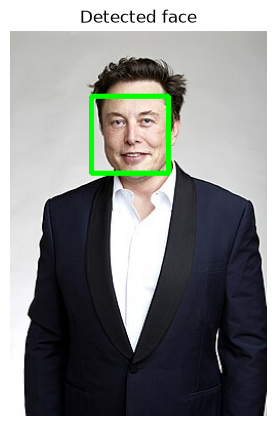

In [7]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

FACE_RECOGNITION_AVAILABLE = True
try:
    import face_recognition
except ImportError:
    FACE_RECOGNITION_AVAILABLE = False
    print("face_recognition not installed - using OpenCV-only fallback (detection works, "
          "encoding is a simpler fallback vector rather than a true 128-d embedding).")


def detect_and_encode_face(image_path):
    image = cv2.imread(image_path)
    if image is None:
        raise FileNotFoundError(f"Could not read image at '{image_path}'. Check IMAGE_PATH in the config cell.")
    rgb_image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    if FACE_RECOGNITION_AVAILABLE:
        face_locations = face_recognition.face_locations(rgb_image)
        if not face_locations:
            raise ValueError("No face detected in the image. Try a clearer, front-facing photo.")
        encodings = face_recognition.face_encodings(rgb_image, face_locations)
        return rgb_image, face_locations, np.array(encodings[0]), "face_recognition (128-d)"
    else:
        cascade_path = cv2.data.haarcascades + "haarcascade_frontalface_default.xml"
        cascade = cv2.CascadeClassifier(cascade_path)
        gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
        faces = cascade.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=5)
        if len(faces) == 0:
            raise ValueError("No face detected in the image. Try a clearer, front-facing photo.")
        x, y, w, h = faces[0]
        face_locations = [(y, x + w, y + h, x)]  # (top, right, bottom, left) to match face_recognition's format
        face_crop = cv2.resize(gray[y:y + h, x:x + w], (64, 64))
        fallback_encoding = (face_crop.flatten() / 255.0)
        return rgb_image, face_locations, fallback_encoding, "OpenCV fallback (4096-d pixel vector)"


rgb_image, face_locations, face_encoding, encoding_method = detect_and_encode_face(IMAGE_PATH)

print(f"Face(s) detected: {len(face_locations)}")
print(f"Encoding method : {encoding_method}")
print(f"Encoding shape  : {face_encoding.shape}")

# Visualize the detected face with a bounding box
display_img = rgb_image.copy()
for (top, right, bottom, left) in face_locations:
    cv2.rectangle(display_img, (left, top), (right, bottom), (0, 255, 0), 3)

plt.figure(figsize=(5, 5))
plt.imshow(display_img)
plt.axis("off")
plt.title("Detected face")
plt.show()


## 3. Stage 2 — Web / social media search
SerpApi's reverse-image-search endpoint needs a **publicly reachable image URL**, not a local file.
So we first anonymously upload the image to a free host (tries `uguu.se`, then `tmpfiles.org`, then
`catbox.moe`) to get a temporary public URL, then hand that URL to SerpApi — trying the
`google_reverse_image` engine first and falling back to `google_lens`. It's a genuine live search,
not a hardcoded result.

If every host is blocked in your environment, set `PUBLIC_IMAGE_URL` in the CONFIG cell to any
publicly accessible image URL and rerun.

In [8]:
import os
import requests

# Free anonymous image hosts, tried in order. No account or API key needed.
def _upload_uguu(path, filename):
    with open(path, "rb") as f:
        r = requests.post("https://uguu.se/upload.php",
                          files={"files[]": (filename, f, "application/octet-stream")}, timeout=60)
    r.raise_for_status()
    return r.json()["files"][0]["url"]

def _upload_tmpfiles(path, filename):
    with open(path, "rb") as f:
        r = requests.post("https://tmpfiles.org/api/v1/upload",
                          files={"file": (filename, f, "application/octet-stream")}, timeout=60)
    r.raise_for_status()
    page_url = r.json()["data"]["url"]                     # e.g. https://tmpfiles.org/1234/name.jpg
    return page_url.replace("tmpfiles.org/", "tmpfiles.org/dl/", 1)  # direct-download form

def _upload_catbox(path, filename):
    with open(path, "rb") as f:
        r = requests.post("https://catbox.moe/user/api.php",
                          data={"reqtype": "fileupload"},
                          files={"fileToUpload": (filename, f, "application/octet-stream")}, timeout=60)
    r.raise_for_status()
    url = r.text.strip()
    if not url.startswith("http"):
        raise RuntimeError(f"catbox response: {url!r}")
    return url

# uguu.se is first because it returns a clean direct-image URL (https://h.uguu.se/x.jpg)
# that Google/SerpApi can actually fetch. tmpfiles.org serves through a /dl/ redirect that
# the search engine often can't follow, and catbox.moe frequently rejects automated
# uploads ("Invalid uploader"), so both are only fallbacks.
_IMAGE_HOSTS = [("uguu.se", _upload_uguu),
                ("tmpfiles.org", _upload_tmpfiles),
                ("catbox.moe", _upload_catbox)]


def upload_image_get_public_url(image_path):
    """Anonymously host the image so SerpApi can fetch it. Tries several free hosts."""
    if not os.path.exists(image_path):
        raise FileNotFoundError(f"Could not find image file: {image_path}")
    if os.path.getsize(image_path) == 0:
        raise ValueError(f"Image file is empty: {image_path}")

    filename = os.path.basename(image_path)
    errors = []
    for name, fn in _IMAGE_HOSTS:
        try:
            url = fn(image_path, filename)
            print(f"Uploaded via {name}: {url}")
            return url
        except Exception as e:
            errors.append(f"{name}: {e}")
            print(f"  {name} failed ({e}); trying next host...")
    raise RuntimeError(
        "All anonymous image hosts failed. Set PUBLIC_IMAGE_URL in the config cell to a "
        "publicly accessible image URL and rerun this cell.\n  " + "\n  ".join(errors)
    )


def _parse_serpapi_results(data):
    """Normalise results from either the google_reverse_image or google_lens engine."""
    raw = (data.get("image_results")
           or data.get("inline_images")
           or data.get("visual_matches")
           or [])
    out = []
    for r in raw:
        out.append({
            "title": r.get("title", "(no title)"),
            "link": r.get("link") or r.get("source"),
            "source": r.get("source") or r.get("displayed_link", ""),
            "thumbnail": r.get("thumbnail"),
        })
    return out


def reverse_image_search(image_url, api_key):
    """Live reverse image search. Tries google_reverse_image, then falls back to google_lens."""
    headers = {
        "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 "
                      "(KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36"
    }
    attempts = [
        {"engine": "google_reverse_image", "image_url": image_url, "api_key": api_key},
        {"engine": "google_lens", "url": image_url, "api_key": api_key},
    ]
    last_data = {}
    for params in attempts:
        resp = requests.get("https://serpapi.com/search", params=params, headers=headers, timeout=60)
        try:
            resp.raise_for_status()
        except Exception as e:
            print(f"  engine '{params['engine']}' HTTP error: {e}")
            continue
        data = resp.json()
        last_data = data
        if data.get("error"):
            print(f"  engine '{params['engine']}' returned: {data['error']}")
            continue
        results = _parse_serpapi_results(data)
        if results:
            print(f"Search engine used: {params['engine']}")
            return results, data
    return _parse_serpapi_results(last_data), last_data


if not SERPAPI_KEY:
    raise RuntimeError("SERPAPI_KEY is not set. Add it to the config cell or your .env file and rerun.")

if PUBLIC_IMAGE_URL:
    public_image_url = PUBLIC_IMAGE_URL
    print("Using provided public image URL:", public_image_url)
else:
    public_image_url = upload_image_get_public_url(IMAGE_PATH)
    print("Public image URL used for the search:", public_image_url)

search_results, raw_response = reverse_image_search(public_image_url, SERPAPI_KEY)

if not search_results:
    print("No matches found by the search API. Try a different / more distinctive image, "
          "or inspect `raw_response` below for details.")
else:
    print(f"\nFound {len(search_results)} result(s). Showing up to 5:\n")
    for i, r in enumerate(search_results[:5]):
        print(f"[{i}] {r['title']}\n     source: {r['source']}\n     link:   {r['link']}\n")


Uploaded via uguu.se: https://h.uguu.se/VoHLMcrT.jpg
Public image URL used for the search: https://h.uguu.se/VoHLMcrT.jpg
Search engine used: google_reverse_image

Found 9 result(s). Showing up to 5:

[0] Elon Musk
     source: Wikipedia
     link:   https://en.wikipedia.org/wiki/Elon_Musk

[1] ConversationPrints Elon Musk Portrait space tesla ...
     source: Amazon.com
     link:   https://us.amazon.com/ConversationPrints-Portrait-GLOSSY-POSTER-PICTURE/dp/B0DRF93GQS

[2] File:Elon Musk Royal Society.jpg
     source: Wikimedia Commons
     link:   https://commons.wikimedia.org/wiki/File:Elon_Musk_Royal_Society.jpg

[3] "What would you ask Elon Musk if you met him❔ ...
     source: X · DullahTheking2
     link:   https://x.com/DullahTheking2/status/2076662177227010328

[4] Elon musk
     source: Pinterest
     link:   https://in.pinterest.com/utsavnayak7/elon-musk/



In [9]:
# Pick which result counts as your "matched post" for the blockchain stage.
# Defaults to the top result - change the index if a lower result is a better match.
MATCH_INDEX = 0   # <-- EDIT: index into search_results above, if you want a different match

if not search_results:
    raise RuntimeError("No search results to pick from - re-run the search cell above with a different image.")

matched_post = search_results[MATCH_INDEX]
print("Selected matched post:")
print(matched_post)


Selected matched post:
{'title': 'Elon Musk', 'link': 'https://en.wikipedia.org/wiki/Elon_Musk', 'source': 'Wikipedia', 'thumbnail': 'https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcRg8HXLYNsWdPQfZQKGHxll6pY7hdUFeUrfnUVnBm6jwjkjiNAnoAcb&usqp=CAE&s'}


## 4. Stage 3 — Blockchain verification
We build a **fingerprint** (SHA-256 hashes of the input image, the face encoding, and the matched
post's data) and write it to a blockchain — by default a small local simulated chain (hash-linked
blocks, exactly like a real chain's tamper-evidence mechanism), which fully satisfies the task's
"local/simulated chain" option. Section 5 below shows the real-testnet alternative.

In [10]:
import hashlib
import json
import time


class Block:
    def __init__(self, index, data, previous_hash, timestamp=None):
        self.index = index
        self.timestamp = timestamp or time.time()
        self.data = data
        self.previous_hash = previous_hash
        self.hash = self.compute_hash()

    def compute_hash(self):
        block_string = json.dumps(
            {"index": self.index, "timestamp": self.timestamp, "data": self.data, "previous_hash": self.previous_hash},
            sort_keys=True,
        ).encode()
        return hashlib.sha256(block_string).hexdigest()

    def to_dict(self):
        return {
            "index": self.index, "timestamp": self.timestamp, "data": self.data,
            "previous_hash": self.previous_hash, "hash": self.hash,
        }


class SimpleBlockchain:
    def __init__(self):
        self.chain = [self._create_genesis_block()]

    def _create_genesis_block(self):
        return Block(0, {"genesis": True}, "0" * 64)

    def add_block(self, data):
        prev = self.chain[-1]
        block = Block(len(self.chain), data, prev.hash)
        self.chain.append(block)
        return block

    def is_valid(self):
        for i in range(1, len(self.chain)):
            curr, prev = self.chain[i], self.chain[i - 1]
            if curr.hash != curr.compute_hash():
                return False
            if curr.previous_hash != prev.hash:
                return False
        return True

    def find_block_by_content_hash(self, content_hash):
        for block in self.chain:
            if isinstance(block.data, dict) and block.data.get("content_hash") == content_hash:
                return block
        return None


def build_fingerprint(image_path, face_encoding, matched_post):
    """Hash the image, the face encoding, and the matched post into one tamper-evident record."""
    with open(image_path, "rb") as f:
        image_bytes = f.read()
    image_hash = hashlib.sha256(image_bytes).hexdigest()
    encoding_hash = hashlib.sha256(np.asarray(face_encoding).tobytes()).hexdigest()
    post_string = json.dumps(matched_post, sort_keys=True, default=str)
    post_hash = hashlib.sha256(post_string.encode()).hexdigest()

    combined = image_hash + encoding_hash + post_hash
    content_hash = hashlib.sha256(combined.encode()).hexdigest()

    return {
        "image_hash": image_hash,
        "face_encoding_hash": encoding_hash,
        "matched_post_hash": post_hash,
        "matched_post_url": matched_post.get("link") or matched_post.get("source"),
        "matched_post_title": matched_post.get("title"),
        "content_hash": content_hash,
        "created_at": time.time(),
    }


fingerprint = build_fingerprint(IMAGE_PATH, face_encoding, matched_post)
print("Fingerprint built:")
for k, v in fingerprint.items():
    print(f"  {k}: {v}")


Fingerprint built:
  image_hash: c60f60cb2b46c10910d69aa80e8b01d3e400df05312345bb41e2ba4a3609fd45
  face_encoding_hash: b96a046a186aa04791116d642c0d170763b3a26f9391deac2d482f38bcb856eb
  matched_post_hash: e59488b089571befafe39095190b9e31d5703b5e4faa0ff85a7b04f0264bb389
  matched_post_url: https://en.wikipedia.org/wiki/Elon_Musk
  matched_post_title: Elon Musk
  content_hash: b2cd43f5609fe509b76f10d5f2c35340fa9a8ad0ad5b1f05c7076381a32f3aec
  created_at: 1788796859.3403182


In [11]:
blockchain = SimpleBlockchain()
new_block = blockchain.add_block(fingerprint)

print(f"Block #{new_block.index} added to local chain.")
print(f"Block hash      : {new_block.hash}")
print(f"Previous hash   : {new_block.previous_hash}")
print(f"Chain length    : {len(blockchain.chain)}")
print(f"Chain valid?    : {blockchain.is_valid()}")


Block #1 added to local chain.
Block hash      : 2ba907c34e8514870e8100453e5607ef3e5c41503c382642ffd4f4ee584dbe90
Previous hash   : a5db589153aeca6368ed3248d06d7fff376a4837c84d2196f2ededfc16d82e7b
Chain length    : 2
Chain valid?    : True


### 4a. Re-verification (local chain)
This is the step that actually proves tamper-evidence: recompute the fingerprint fresh from the
original image + matched post, and check it against what's stored on the chain.

In [12]:
def verify_on_local_chain(chain, image_path, face_encoding, matched_post):
    recomputed = build_fingerprint(image_path, face_encoding, matched_post)
    found_block = chain.find_block_by_content_hash(recomputed["content_hash"])

    if found_block is not None and chain.is_valid():
        print("VERIFIED - recomputed hash matches the on-chain record. Data is untampered.")
        print(f"   On-chain content_hash : {found_block.data['content_hash']}")
        print(f"   Recomputed content_hash: {recomputed['content_hash']}")
        return True
    else:
        print("VERIFICATION FAILED - hash mismatch or chain invalid. Data may have been tampered with.")
        return False


verify_on_local_chain(blockchain, IMAGE_PATH, face_encoding, matched_post)


VERIFIED - recomputed hash matches the on-chain record. Data is untampered.
   On-chain content_hash : b2cd43f5609fe509b76f10d5f2c35340fa9a8ad0ad5b1f05c7076381a32f3aec
   Recomputed content_hash: b2cd43f5609fe509b76f10d5f2c35340fa9a8ad0ad5b1f05c7076381a32f3aec


True

In [13]:
# --- Optional sanity check: prove the verification actually catches tampering ---
tampered_post = dict(matched_post)
tampered_post["title"] = "This title was changed after the fact"

print("Verifying tampered data (should FAIL):")
verify_on_local_chain(blockchain, IMAGE_PATH, face_encoding, tampered_post)


Verifying tampered data (should FAIL):
VERIFICATION FAILED - hash mismatch or chain invalid. Data may have been tampered with.


False

## 5. (Optional) Real blockchain — Ethereum Sepolia testnet
Only runs if you set `USE_REAL_BLOCKCHAIN = True` in the config cell. No smart contract needed —
we anchor the fingerprint's `content_hash` directly in the `data` field of a zero-value transaction
sent from your testnet wallet to itself. This is a standard, gas-cheap way to timestamp a hash on a
real public chain.

**To use this:**
1. Create a fresh wallet you'll only ever use for testnets (e.g. in MetaMask) — never reuse a real wallet's private key here.
2. Get free Sepolia ETH from a faucet, e.g. https://sepoliafaucet.com or https://www.alchemy.com/faucets/ethereum-sepolia
3. Get a free Sepolia RPC URL from https://www.alchemy.com or https://www.infura.io
4. Fill in `SEPOLIA_RPC_URL` and `WALLET_PRIVATE_KEY` in the config cell, and set `USE_REAL_BLOCKCHAIN = True`, then re-run from the top.

In [ ]:
if USE_REAL_BLOCKCHAIN:
    from web3 import Web3

    w3 = Web3(Web3.HTTPProvider(SEPOLIA_RPC_URL))
    assert w3.is_connected(), "Could not connect to Sepolia RPC - check SEPOLIA_RPC_URL."

    account = w3.eth.account.from_key(WALLET_PRIVATE_KEY)
    print("Using wallet address:", account.address)
    balance = w3.eth.get_balance(account.address)
    print("Balance (ETH):", w3.from_wei(balance, "ether"))

    tx = {
        "nonce": w3.eth.get_transaction_count(account.address),
        "to": account.address,
        "value": 0,
        "gas": 30000,
        "gasPrice": w3.eth.gas_price,
        "data": "0x" + fingerprint["content_hash"],
        "chainId": 11155111,  # Sepolia chain ID
    }

    signed_tx = account.sign_transaction(tx)
    tx_hash = w3.eth.send_raw_transaction(signed_tx.raw_transaction)
    print("Transaction submitted!")
    print("Tx hash:", tx_hash.hex())
    print("View on Etherscan:", f"https://sepolia.etherscan.io/tx/{tx_hash.hex()}")

    print("\nWaiting for confirmation...")
    receipt = w3.eth.wait_for_transaction_receipt(tx_hash, timeout=180)
    print("Confirmed in block:", receipt.blockNumber)
else:
    print("USE_REAL_BLOCKCHAIN is False - skipping. The local simulated chain above already "
          "satisfies the task's blockchain requirement.")


In [ ]:
def verify_on_sepolia(w3, tx_hash, expected_content_hash):
    tx = w3.eth.get_transaction(tx_hash)
    onchain_hex = tx["input"].hex().replace("0x", "")
    if onchain_hex == expected_content_hash:
        print("VERIFIED on Sepolia testnet - on-chain data matches the recomputed fingerprint.")
        return True
    else:
        print("MISMATCH - on-chain data does not match the recomputed fingerprint.")
        return False


if USE_REAL_BLOCKCHAIN:
    verify_on_sepolia(w3, tx_hash, fingerprint["content_hash"])


## 6. End-to-end summary
Quick recap printout of everything the pipeline produced — useful to have on screen for your recording.

In [14]:
print("=" * 60)
print("PIPELINE SUMMARY")
print("=" * 60)
print(f"1) Face detected via: {encoding_method}")
print(f"   Encoding shape    : {face_encoding.shape}")
print()
print(f"2) Matched post found via live reverse image search:")
print(f"   Title : {matched_post.get('title')}")
print(f"   Link  : {matched_post.get('link') or matched_post.get('source')}")
print()
print(f"3) Blockchain record:")
if USE_REAL_BLOCKCHAIN:
    print(f"   Mode      : REAL Ethereum Sepolia testnet")
    print(f"   Tx hash   : {tx_hash.hex()}")
    print(f"   Etherscan : https://sepolia.etherscan.io/tx/{tx_hash.hex()}")
else:
    print(f"   Mode         : Local simulated blockchain")
    print(f"   Block index  : {new_block.index}")
    print(f"   Block hash   : {new_block.hash}")
print(f"   Content hash : {fingerprint['content_hash']}")
print("=" * 60)


PIPELINE SUMMARY
1) Face detected via: face_recognition (128-d)
   Encoding shape    : (128,)

2) Matched post found via live reverse image search:
   Title : Elon Musk
   Link  : https://en.wikipedia.org/wiki/Elon_Musk

3) Blockchain record:
   Mode         : Local simulated blockchain
   Block index  : 1
   Block hash   : 2ba907c34e8514870e8100453e5607ef3e5c41503c382642ffd4f4ee584dbe90
   Content hash : b2cd43f5609fe509b76f10d5f2c35340fa9a8ad0ad5b1f05c7076381a32f3aec


---
### Notes for your README
- **Face ID**: `face_recognition` (dlib 128-d embeddings), OpenCV fallback if unavailable.
- **Search**: SerpApi `google_reverse_image` engine (falls back to `google_lens`); image hosted anonymously via `uguu.se` / `tmpfiles.org` / `catbox.moe` for a public URL. Genuine live search each run — no hardcoded results.
- **Blockchain**: local SHA-256 hash-linked chain by default; optional real anchor on Ethereum Sepolia testnet via a zero-value self-transaction carrying the hash in its `data` field (no smart contract deployment needed).
- **Known limitations**: reverse image search quality depends on the image being publicly indexed elsewhere already; free API tiers are rate-limited; free image hosts occasionally block automated uploads (set `PUBLIC_IMAGE_URL` to work around it); OpenCV fallback encoding is not a true face-recognition embedding, only a placeholder to keep the pipeline running.